In [2]:
import scipy.io as sio
import mat73
import numpy as np
import jax.numpy as jnp
import jax
#data_dict = mat73.loadmat('data.mat')
import matplotlib.pyplot as plt
import pandas as pd
import math
import os
from functools import partial
from jax import random

plt.rcParams.update({'font.size': 12})
import matplotlib
matplotlib.rcParams['pdf.fonttype']=42

def loadData(monkey_name):
    folder_name='/mnt/homes/@LH-CORNELL.EDU/61/cc2465-1000003/projects/THINGS/TVSD/'
    #monkey_name='N'

    
    full_name='monkey'+monkey_name
    file_name='THINGS_normMUA.mat'
    path=folder_name+full_name+'/'+file_name
    
    mat_data = mat73.loadmat(path)
    if monkey_name=='F':
        rois = np.zeros(1024)#; % V1
        rois[512:832] = 2#; % IT
        rois[832:] = 1#; % V4
    
    elif monkey_name=='N':
        rois = np.zeros(1024) # V1
        rois[512:768] = 1 # V4
        rois[768:] = 2 # IT
    
    
    image_labels=mat73.loadmat(folder_name+full_name+'/'+'things_imgs.mat')
    #image_labels['train_imgs']['things_path']
    
    classes=np.array(image_labels['train_imgs']['class'])
    class_name,class_label=np.unique(classes,return_inverse=True)
    
    
    SNR=np.array(mat_data['SNR'])
    train_MUA=mat_data['train_MUA']
    
    arrayID=np.repeat(np.arange(16),64)
    
    # For monkey N, this plot should show that array 5 is empty.
    # So we need to create a mask for that monkey
    if monkey_name=='N':
        validArrays = arrayID!=5 
        rois = rois[validArrays]
        arrayID=np.repeat(np.arange(15),64)
        SNR=SNR[validArrays,:]
        train_MUA=train_MUA[validArrays,:]
    

    if monkey_name=='F':
        idx=np.arange(1024)
        idx=np.concatenate([idx[rois==0],idx[rois==1],idx[rois==2]])
        train_MUA=train_MUA[idx,:]
        rois=rois[idx]
        # DO NOT REORDER ARRAY ID.
        
    return train_MUA,class_name,class_label,classes,arrayID,rois




def gett_all(ijlm, A):
    i, j, l, m = list(ijlm)
    pexp = i+'a,'+j+'a,'+l+'b,'+m+'b->'
    qexp = i+'a,'+j+'a,'+l+'a,'+m+'a->'
    pval = jnp.einsum(pexp, A, A, A, A)
    pqval = pval - jnp.einsum(qexp, A, A, A, A)
    return pval,pqval

@partial(jax.jit, static_argnames=['P','Q'])
def getest_all0(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    #Xs1=Xs1_o-jnp.sum(Xs1_o,axis=0)/P
    #Xs2=Xs2_o-jnp.sum(Xs2_o,axis=0)/P

    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))/P
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))/Q
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=1)/Q ))/P
    Term3=-(1-Qhr)/Q * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=0)/P ))/Q
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.sum(jnp.power(Xs1*Xs2,2))/(P*Q)
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.sum(Xs1*Xs2)/(P*Q))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp
    
@partial(jax.jit, static_argnames=['P','Q'])
def getest_all(A,P,Q):
    nf = jnp.sqrt(P)*jnp.sqrt(Q)
    # Wrap *all* the following in a single shared_intermediates context
    #with shared_intermediates():
    t1,t1d = gett_all('ijji', A/nf)
    t2,t2d = gett_all('iiii', A/nf)
    t3,t3d = gett_all('ijjj', A/nf)
    #t4,t4d = gett_all('iiij', A/nf)#<
    t5,t5d = gett_all('ijjl', A/nf)
    t6,t6d = gett_all('iijj', A/nf)
    t7,t7d = gett_all('iijl', A/nf)
    #t8,t8d = gett_all('ijll', A/nf)#<
    t9,t9d = gett_all('ijlm', A/nf)

    f1 = P / (P - 2)
    f2 = 2 / (P - 2)
    f3 = (1/(P-1))*(1/(P-2))

    denom_n = t1 - 2/P * t5 + (1/P)**2 * t9
    denom_s = P/(P-3) * (
        t1
        - f1 * t2
        + f2 * (2*t3 - t5)
        + f3 * (t6 - 2*t7 + t9)
    )
    denom_d = (P/(P-3))*(Q/(Q-1)) * (
        t1d
        - f1 * t2d
        + f2 * (2*t3d - t5d)
        + f3 * (t6d - 2*t7d + t9d)
    )

    numer_n = t6 - 2/P * t7 + (1/P)**2 * t9
    numer_s = P/(P-3) * (
        t6 
        - 2/(P-1) * t7 
        + 1/(P-2) * (4*t3 - P*t2) 
        + f3 * (t9 - 4*t5 + 2*t1 - t6) 
    )
    numer_d = (P/(P-3))*(Q/(Q-1))*(
        t6d 
        - 2/(P-1) * t7d 
        + 1/(P-2) * (4*t3d - P*t2d) 
        + f3 * (t9d - 4*t5d + 2*t1d - t6d) 
    )

    numer_s_col = t6d - 2/P * t7d + (1/P)**2 * t9d
    denom_s_col = t1d - 2/P * t5d + (1/P)**2 * t9d
    
    
    naive=[numer_n, denom_n]
    row_exp=[numer_s,  denom_s]
    col_exp=[numer_s_col, denom_s_col]
    double_exp=[numer_d, denom_d]
    
    
    return naive, row_exp, col_exp, double_exp



In [3]:
# Load the data

names=['F','N']

Ms=[]
class_names=[]
class_labels=[]
arrayIDs=[]
roiss=[]
for name in names:
    train_MUA,class_name,class_label,classes,arrayID,rois=loadData(name)
    Ms.append(jnp.array(train_MUA.T))
    class_names.append(classes)
    class_labels.append(class_label)
    arrayIDs.append(arrayID)
    roiss.append(rois)
    del train_MUA,class_name,class_label,arrayID,rois,classes

    

2025-03-21 17:40:27.758368: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [11]:
np.shape(np.arange(np.shape(Phi_o_a)[0]))

(22248,)

In [4]:
#%%timeit
#m0_count=int(np.max(roiss[0])+1)
#m1_count=int(np.max(roiss[1])+1)

Qs=[8,16, 32, 64, 128]#, 128]

P=1000

numit=1000
Aiqri=[]
Qsss=[]
for i in [0,1]:
    Aiqr=[]
    Qss=[]
    for roi_idx in [0,1,2]:
        Phi_o_a=Ms[i][:,roiss[i]==roi_idx]
        Qs=np.power(10,np.linspace(np.log10(32),np.log10(np.shape(Phi_o_a)[1]), 6 )).astype(int)
        Qss.append(Qs)
        
        Aiq=[]
        for Q in Qs:
            print('\r {}, {}, {}'.format(i,roi_idx,Q),end='')
            Ai=[]
            for itr in range(numit):
                idxa=np.random.choice(np.arange(np.shape(Phi_o_a)[1]),Q,replace=False)
                
                idx_P=np.random.choice(np.arange(np.shape(Phi_o_a)[0]),P,replace=False)
                Phi_a=Phi_o_a[:,idxa][idx_P,:]
                
                Ai.append(list(getest_all(Phi_a,P,Q)))
            Aiq.append(Ai)
        Aiqr.append(Aiq)
    Aiqri.append(Aiqr)
    Qsss.append(Qss)
Aiqri=np.array(Aiqri)
Qsss=np.array(Qsss)


 1, 2, 256

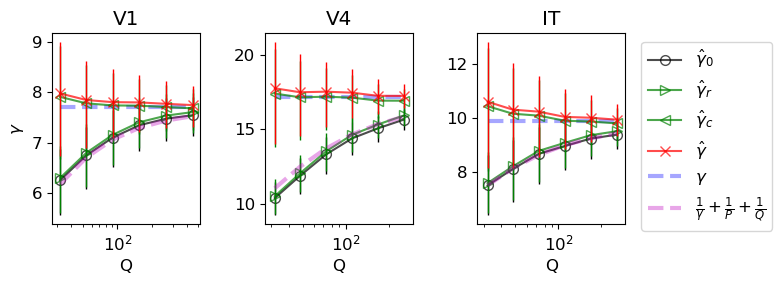

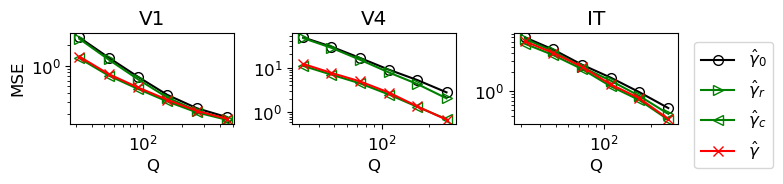

In [10]:
mid=1

fig,axs=plt.subplots(1,3,figsize=(8,3))

fig2,axs2=plt.subplots(1,3,figsize=(8,2))

roi_names=['V1','V4','IT']

Aiqr=Aiqri[mid]
Qss=Qsss[mid]
for roi_idx in [0,1,2]:
    Aiq=Aiqr[roi_idx]
    Qs=Qss[roi_idx]

    numer,denom=np.mean(Aiq[-1,:,-1,0],axis=0), np.mean(Aiq[-1,:,-1,1],axis=0)
    gamma=numer/denom

    ax=axs[roi_idx]
    ax2=axs2[roi_idx]
    
    ms=7
    
    alpha=0.7
    
    xoi=Qs


    ls='-'
    lw=1.5
    
    colorvs=['k','g','g','r']
    markers=['o','>','<','x']
    labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
    for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
        numer, denom = Aiq[:,:,i,0], Aiq[:,:,i,1]
    
        qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
        
        
        yval=np.nanmedian(qoi,axis=1)
        lower_error=np.nanquantile(qoi,axis=1,q=0.25)
        upper_error=np.nanquantile(qoi,axis=1,q=0.75)
        asymmetric_error = [yval-lower_error, upper_error-yval]
        #yval=np.mean(qoi,axis=1)
        asymmetric_error = [np.std(qoi,axis=1),np.std(qoi,axis=1)]
        ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
        yval=np.nanmean(qoi,axis=1)
        ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')
    
        #ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
        ax2.plot(xoi,np.mean(np.square(gamma-qoi),axis=1), c=colorv,ms=ms,marker=marker,ls=ls,fillstyle='none',label=label)
    
    
    ax.plot(xoi,xoi*0+gamma,c='b',ls='--',label=r'$\gamma$',zorder=-10,alpha=0.35,lw=3)
    ax.plot(xoi,1/(1/xoi+1/P+1/gamma),c='m',ls='--',alpha=0.35,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')
    
    ax.set_xlabel('Q')
    ax.set_xscale('log')
    ax2.set_xlabel('Q')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    
    ax.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
    ax2.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])

    #ax.set_ylim([
    ax.set_title(roi_names[roi_idx])
    ax2.set_title(roi_names[roi_idx])
    

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

axs2[0].set_ylabel('MSE')
    #for q in range(100):
axs[0].set_ylabel(r'$\gamma$')

fig.tight_layout()
fig2.tight_layout()


fig.savefig("tvsd_dim.pdf", bbox_inches='tight')
fig2.savefig("tvsd_dim_mse.pdf", bbox_inches='tight')



In [6]:
meta_path='/mnt/homes/@LH-CORNELL.EDU/61/cc2465-1000003/projects/THINGS/images/meta/'

category_file='category53_wide-format.tsv'

data = pd.read_csv(meta_path+category_file, sep = '\t')

data

,uniqueID,Word,animal,arts and crafts supply,bird,body part,breakfast food,candy,clothing,clothing accessory,...,sea animal,seafood,sports equipment,tool,toy,vegetable,vehicle,watercraft,weapon,women's clothing
0,aardvark,aardvark,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,abacus,abacus,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,accordion,accordion,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,acorn,acorn,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,air_conditioner,air conditioner,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,yoke,yoke,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1850,yolk,yolk,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1851,zebra,zebra,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1852,zipper,zipper,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
sumv=data.sum().values[2:]
catli=data.sum().index[2:]
sortID=np.argsort(sumv)
sorted_list=np.array([catli,sumv])[:,sortID]
sorted_list = {'name': sorted_list[0,:], 'count':sorted_list[1,:]} 

print(pd.DataFrame(sorted_list))
#sum_values = data.sum(axis=0)

# Step 3: Sort the sums in descending order (change to ascending=True if desired)
#sorted_sum = sum_values.sort_values(ascending=False)
#print(sorted_sum)
#sel_cats=['mammal', 'vegetable', 'vehicle', 'lighting']
#sel_cats=['garden tool', 'animal','furniture', 'insect']
#sel_cats=['tool','clothing','animal','food']

#sel_cats=['monkey','pencil','armor','bee']

#50                clothing   108
#51                  animal   177
#52                    food   295

#sel_catss=[['furniture','game','animal','vegetable'],
#          ['lighting','vehicle', 'plant','mammal'],
#          ['clothing','container', 'fruit', 'farm animal']]

#sel_catss=[['furniture','game','animal','fruit'],
#          ['jewelry','vehicle', 'plant','mammal'],
#          ['lighting','container', 'vegetable', 'farm animal']]

#sel_catss=[['condiment','footwear','animal','fruit'],
#          ['protective clothing','kitchen appliance', 'plant','bird'],
#          ['lighting','office supply', 'vegetable', 'farm animal']]

#sel_catss=[['condiment','game','animal','fruit'],
#          ['safety equipment','school supply', 'food','bird'],
#          ['lighting','office supply', 'vegetable', 'farm animal']]

#sel_catss=[['tool','clothing','electronic device','sports equipment'],
#          ['jewelry','condiment', 'footwear','protective clothing'],
#          ['jewelry','condiment', 'footwear', 'bird']]


                      name count
0                  jewelry    15
1                condiment    15
2                 footwear    15
3      protective clothing    16
4                outerwear    16
5                 lighting    16
6                    candy    16
7                   insect    17
8              garden tool    17
9              farm animal    18
10              watercraft    19
11                headwear    19
12                    game    19
13                   drink    19
14       kitchen appliance    20
15        women's clothing    20
16        safety equipment    21
17                 seafood    24
18           office supply    25
19           school supply    26
20                    bird    27
21       medical equipment    27
22            kitchen tool    27
23  construction equipment    28
24              sea animal    30
25             part of car    30
26   personal hygiene item    31
27                fastener    32
28      musical instrument    33
29        

In [8]:
sel_cats=['farm animal', 'insect', 'container', 'clothing']

def get_masks_for_things(sel_cats,data,class_names, is_cat=True, show=False):
    omas=[]
    for catn in sel_cats:
        if is_cat:
            if show: print(catn)
            uID=data['uniqueID'].values
            
            cat_mask=data[catn].values==1
            sel_objs=uID[cat_mask]
            if show: print(sel_objs)
            #[data[catn].values==1]
            
            assert (class_names[0]==class_names[1]).all()
            class_name=class_names[0]
            objs_mask=np.zeros(np.shape(class_name)[0])==1
            for sel_obj in sel_objs:
                objs_mask += class_name==sel_obj
            
            if show: print(np.sum(objs_mask))
            omas.append(objs_mask)
        else:
            assert (class_names[0]==class_names[1]).all()
            class_name=class_names[0]
            if show: print(np.sum(class_name==catn))
            omas.append(class_name==catn)
    return omas

masks=[get_masks_for_things(sel_cats,data,class_names, is_cat=True, show=False)]
masks=np.squeeze(np.array(masks))
print(np.sum(masks,axis=1))

[ 216  204 1260 1296]


In [9]:
#oid=0
#mid=0
dim_o_m_r_s=[]
for oid in range(len(sel_cats)):
    dim_m_r_s=[]
    for mid in range(2):
        dim_r_s=[]
        for roi_idx in range(3):
            
            Phi_o_a=Ms[mid][:,roiss[mid]==roi_idx]
            
            Q=np.shape(Phi_o_a)[-1]
            idxa=np.random.choice(np.arange(np.shape(Phi_o_a)[1]),Q,replace=False)
            idx_P=masks[oid]
            
            Phi=Phi_o_a[:,idxa][idx_P,:]
            
            A=np.squeeze(np.array([getest_all0(Phi,Phi,P,Q)]))
            dims=A[:,0]/A[:,1]
            
            dim_r_s.append(dims)
        dim_m_r_s.append(dim_r_s)
    dim_o_m_r_s.append(dim_m_r_s)
dim_o_m_r_s=np.array(dim_o_m_r_s)


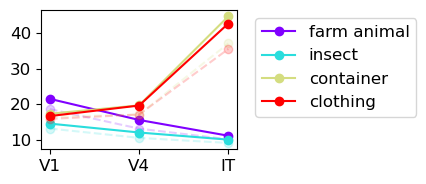

In [205]:
mid=0
dim_o_r_s=dim_o_m_r_s[:,mid,:,:]

xs=np.arange(3)

color = plt.cm.rainbow(np.linspace(0, 1,len(sel_cats)))

fig,ax=plt.subplots(1,1,figsize=(4.5,2.))
for oid in range(len(sel_cats)):
    naiv=dim_o_r_s[oid,:,0]
    ours=dim_o_r_s[oid,:,-1]
    ax.plot(xs,naiv,alpha=0.2,ls='--',marker='o',c=color[oid])
    ax.plot(xs,ours,alpha=1,ls='-',marker='o',c=color[oid],label=sel_cats[oid])
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

ax.set_xticks(xs, ['V1','V4','IT'], rotation=0)
fig.tight_layout()
fig.savefig("tvsd_cat_dim.pdf", bbox_inches='tight')



In [9]:
all_cats=np.array(pd.DataFrame(sorted_list))[:,0]
print(all_cats)

masks=[get_masks_for_things(all_cats,data,class_names, is_cat=True, show=False)]
masks=np.squeeze(np.array(masks))

dim_o_m_r_s=[]
for oid in range(len(all_cats)):
    dim_m_r_s=[]
    for mid in range(2):
        dim_r_s=[]
        for roi_idx in range(3):
            
            Phi_o_a=Ms[mid][:,roiss[mid]==roi_idx]
            
            Q=np.shape(Phi_o_a)[-1]
            idxa=np.random.choice(np.arange(np.shape(Phi_o_a)[1]),Q,replace=False)
            idx_P=masks[oid]
            
            Phi=Phi_o_a[:,idxa][idx_P,:]
            
            A=np.squeeze(np.array([getest_all0(Phi,Phi,P,Q)]))
            dims=A[:,0]/A[:,1]
            
            dim_r_s.append(dims)
        dim_m_r_s.append(dim_r_s)
    dim_o_m_r_s.append(dim_m_r_s)
dim_o_m_r_s=np.array(dim_o_m_r_s)


['jewelry' 'condiment' 'footwear' 'protective clothing' 'outerwear'
 'lighting' 'candy' 'insect' 'garden tool' 'farm animal' 'watercraft'
 'headwear' 'game' 'drink' 'kitchen appliance' "women's clothing"
 'safety equipment' 'seafood' 'office supply' 'school supply' 'bird'
 'medical equipment' 'kitchen tool' 'construction equipment' 'sea animal'
 'part of car' 'personal hygiene item' 'fastener' 'musical instrument'
 'toy' 'fruit' 'body part' 'breakfast food' 'scientific equipment'
 'dessert' 'clothing accessory' 'home appliance' 'furniture' 'vegetable'
 'arts and crafts supply' 'home decor' 'plant' 'weapon' 'sports equipment'
 'vehicle' 'electronic device' 'hardware' 'mammal' 'container' 'tool'
 'clothing' 'animal' 'food']


['mammal' 'farm animal' 'bird' 'animal' 'headwear' 'outerwear' 'toy'
 'body part' 'protective clothing' 'insect' 'sea animal' 'clothing'
 'school supply' 'clothing accessory' 'office supply' 'watercraft'
 'home decor' 'safety equipment' 'game' "women's clothing" 'seafood'
 'part of car' 'medical equipment' 'vehicle' 'fastener'
 'personal hygiene item' 'sports equipment' 'furniture' 'home appliance'
 'breakfast food' 'dessert' 'container' 'arts and crafts supply' 'weapon'
 'construction equipment' 'lighting' 'scientific equipment'
 'kitchen appliance' 'hardware' 'plant' 'vegetable' 'jewelry' 'food'
 'tool' 'electronic device' 'fruit' 'garden tool' 'kitchen tool'
 'musical instrument' 'condiment' 'drink' 'footwear' 'candy']


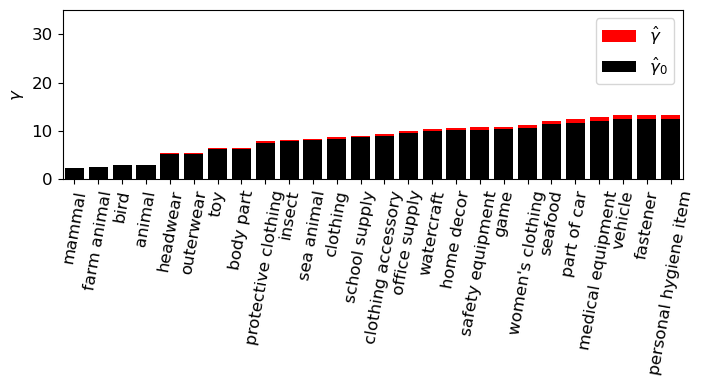

In [10]:
mid=1
dim_o_r_s=dim_o_m_r_s[:,mid,:,:]

est=-2
dim_o_r=dim_o_r_s[:,:,est]
ndim_o_r=dim_o_r_s[:,:,0]

roi=2
dimo = dim_o_r[:,roi]
ndimo = ndim_o_r[:,roi]

sortID=np.argsort(dimo) #-dim_o_r[:,0]
dimo=dimo[sortID]
ndimo=ndimo[sortID]
all_cats_sorted=all_cats[sortID]

xs=np.arange(len(all_cats_sorted))

print(all_cats_sorted)


fig,ax=plt.subplots(1,1,figsize=(8,2.2))
ax.bar(xs, dimo,color='r',label=r'$\hat{\gamma}$')
ax.bar(xs, ndimo,alpha=1,color='k',label=r'$\hat{\gamma}_0$')
ax.set_xticks(xs, all_cats_sorted, rotation=80)
ax.set_xlim([-0.5,25.5])
ax.set_ylabel(r'$\gamma$')
ax.legend()
ax.set_ylim([0,35])
fig.savefig("tvsd_all_cat_dim_roi{}_mid{}.pdf".format(roi,mid), bbox_inches='tight')



['mammal' 'farm animal' 'bird' 'animal' 'insect' 'headwear'
 'safety equipment' 'toy' 'sea animal' 'protective clothing' 'footwear'
 'vegetable' 'fruit' 'kitchen tool' 'seafood' 'body part' 'plant'
 'watercraft' 'kitchen appliance' 'condiment' 'fastener' 'drink'
 'outerwear' 'construction equipment' 'jewelry' 'lighting' 'game'
 "women's clothing" 'breakfast food' 'clothing accessory' 'vehicle'
 'personal hygiene item' 'tool' 'garden tool' 'hardware' 'home appliance'
 'electronic device' 'office supply' 'sports equipment' 'candy'
 'musical instrument' 'arts and crafts supply' 'furniture' 'food'
 'school supply' 'dessert' 'home decor' 'weapon' 'part of car'
 'scientific equipment' 'medical equipment' 'clothing' 'container']


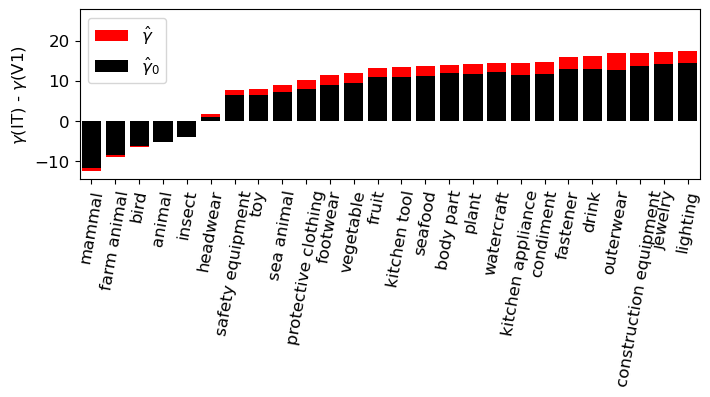

In [12]:
mid=0
dim_o_r_s=dim_o_m_r_s[:,mid,:,:]

est=-2
dim_o_r=dim_o_r_s[:,:,est]
ndim_o_r=dim_o_r_s[:,:,0]

dimo = dim_o_r[:,2]-dim_o_r[:,0]
ndimo = ndim_o_r[:,2]-ndim_o_r[:,0]

sortID=np.argsort(dimo) #-dim_o_r[:,0]
dimo=dimo[sortID]
ndimo=ndimo[sortID]
all_cats_sorted=all_cats[sortID]

xs=np.arange(len(all_cats_sorted))

print(all_cats_sorted)


fig,ax=plt.subplots(1,1,figsize=(8,2.2))
ax.bar(xs, dimo,color='r',label=r'$\hat{\gamma}$')
ax.bar(xs, ndimo,alpha=1,color='k',label=r'$\hat{\gamma}_0$')
ax.set_xticks(xs, all_cats_sorted, rotation=80)
ax.set_xlim([-0.5,25.5])
ax.set_ylabel(r'$\gamma$(IT) - $\gamma$(V1)')
ax.legend()
#ax.set_ylim([0,35])
fig.savefig("tvsd_all_cat_dim_diff_mid{}.pdf".format(mid), bbox_inches='tight')

